In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
import community as community_louvain  # pip install python-louvain
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
import string

# Téléchargement des ressources NLTK (à exécuter une fois)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-eng', quiet=True)

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

[nltk_data] Error loading omw-eng: Package 'omw-eng' not found in
[nltk_data]     index


In [33]:
def load_enriched_data():
    """Charge les données enrichies de la phase 2"""
    try:
        df = pd.read_csv('./data/cleaned/reddit_boycott_enriched.csv')
        print(f"Données chargées: {len(df)} posts")
        return df
    except:
        print("Fichier non trouvé. Chargement depuis pickle...")
        df = pd.read_pickle('./data/cleaned/reddit_boycott_combined.pkl')
        return df

# Chargement
df = load_enriched_data()
print(f"Colonnes disponibles: {list(df.columns)}")

Données chargées: 501 posts
Colonnes disponibles: ['author_fullname', 'source_file', 'ups', 'score', 'over_18', 'downs', 'permalink', 'num_comments', 'selftext', 'subreddit', 'selftext_length', 'created_utc', 'author', 'link_flair_text', 'total_awards_received', 'downs_calculated', 'created_local_formatted', 'created_local', 'id', 'edited', 'title', 'created_utc_formatted', 'upvote_ratio', 'post_type', 'subreddit_subscribers', 'locked', 'created_date', 'created_month', 'created_week', 'created_year_month', 'day_of_week', 'hour_of_day']


In [6]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hibab\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [34]:
class TextPreprocessor:
    """Classe pour le prétraitement textuel avancé"""
    
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
        
        # Ajout de stopwords spécifiques au domaine
        self.domain_stopwords = {
            'reddit', 'http', 'https', 'www', 'com', 'org', 'net',
            'like', 'just', 'get', 'got', 'going', 'know', 'think',
            'really', 'would', 'could', 'should', 'also', 'one', 'two'
        }
        self.stop_words.update(self.domain_stopwords)
        
    def clean_text(self, text):
        """Nettoyage de base du texte"""
        if not isinstance(text, str):
            return ""
        
        # Convertir en minuscules
        text = text.lower()
        
        # Supprimer les URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Supprimer les mentions Reddit
        text = re.sub(r'/?u/\w+', '', text)  # Mentions d'utilisateurs
        text = re.sub(r'/r/\w+', '', text)   # Mentions de subreddits
        
        # Supprimer la ponctuation et les chiffres
        text = re.sub(r'[^\w\s]', ' ', text)
        text = re.sub(r'\d+', '', text)
        
        # Supprimer les espaces multiples
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def tokenize_and_lemmatize(self, text):
        """Tokenisation et lemmatisation"""
        tokens = word_tokenize(text)
        
        # Lemmatisation et filtrage
        tokens = [self.lemmatizer.lemmatize(token) for token in tokens 
                 if token not in self.stop_words and len(token) > 2]
        
        return tokens
    
    def preprocess_document(self, text):
        """Prétraitement complet d'un document"""
        cleaned = self.clean_text(text)
        tokens = self.tokenize_and_lemmatize(cleaned)
        return ' '.join(tokens)
    
    def preprocess_corpus(self, texts):
        """Prétraitement d'un corpus complet"""
        return [self.preprocess_document(text) for text in texts]

# Initialisation du préprocesseur
preprocessor = TextPreprocessor()

# Combiner titre et texte pour analyse
print("Combinaison des titres et textes...")
df['combined_text'] = df['title'] + ' ' + df['selftext'].fillna('')

# Prétraitement
print("Prétraitement textuel en cours...")
df['processed_text'] = preprocessor.preprocess_corpus(df['combined_text'])

# Statistiques de prétraitement
print(f"\nStatistiques après prétraitement:")
print(f"  - Longueur moyenne du texte original: {df['combined_text'].str.len().mean():.0f} caractères")
print(f"  - Longueur moyenne du texte traité: {df['processed_text'].str.len().mean():.0f} caractères")
print(f"  - Posts avec texte vide après traitement: {(df['processed_text'].str.strip() == '').sum()}")

Combinaison des titres et textes...
Prétraitement textuel en cours...

Statistiques après prétraitement:
  - Longueur moyenne du texte original: 370 caractères
  - Longueur moyenne du texte traité: 210 caractères
  - Posts avec texte vide après traitement: 4



Top 30 mots les plus fréquents:
  israel: 206
  boycott: 137
  israeli: 102
  gaza: 94
  people: 84
  support: 80
  palestine: 79
  palestinian: 72
  brand: 72
  company: 72
  want: 60
  zionist: 60
  alternative: 56
  genocide: 56
  bd: 54
  list: 51
  still: 49
  time: 48
  year: 47
  even: 47
  child: 45
  anyone: 43
  family: 42
  war: 42
  good: 41
  safe: 40
  thing: 40
  free: 39
  say: 39
  boycotting: 39

Statistiques du vocabulaire:
  - Nombre total de mots: 14829
  - Vocabulaire unique: 4449
  - Ratio mots uniques/total: 0.300


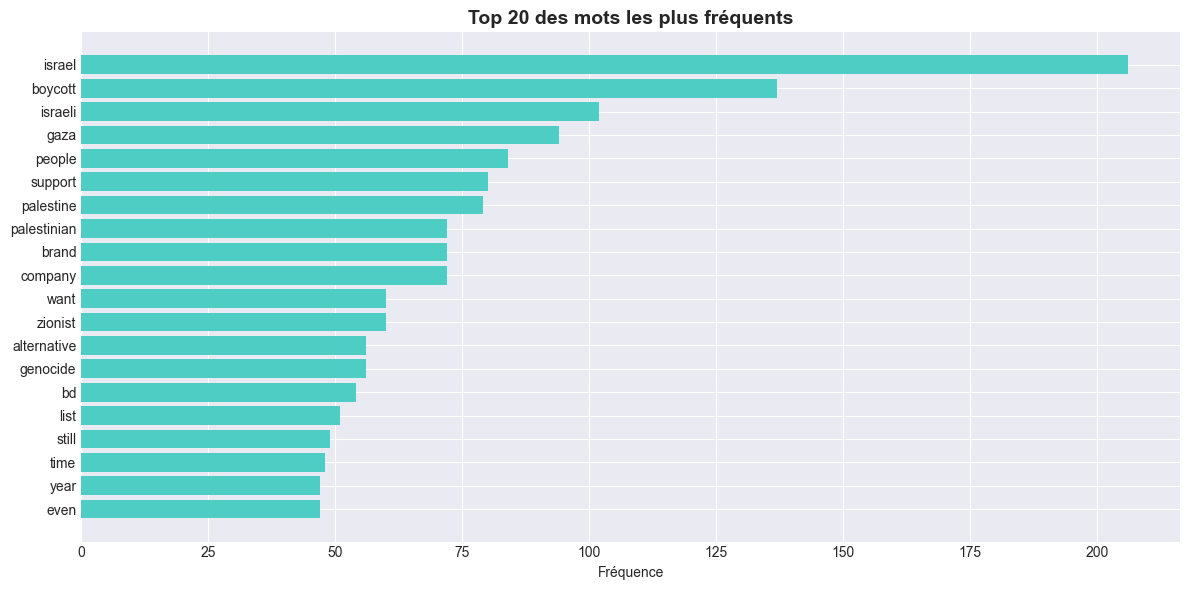

In [35]:
def explore_vocabulary(texts, top_n=50):
    """Explore le vocabulaire du corpus"""
    # Concaténer tous les textes
    all_text = ' '.join(texts)
    
    # Tokenisation simple
    tokens = all_text.split()
    
    # Comptage des mots
    word_counts = Counter(tokens)
    
    print(f"\nTop {top_n} mots les plus fréquents:")
    for word, count in word_counts.most_common(top_n):
        print(f"  {word}: {count}")
    
    # Statistiques
    print(f"\nStatistiques du vocabulaire:")
    print(f"  - Nombre total de mots: {len(tokens)}")
    print(f"  - Vocabulaire unique: {len(word_counts)}")
    print(f"  - Ratio mots uniques/total: {len(word_counts)/len(tokens):.3f}")
    
    return word_counts

# Exploration du vocabulaire
word_counts = explore_vocabulary(df['processed_text'], top_n=30)

# Visualisation des mots fréquents
plt.figure(figsize=(12, 6))
top_words = word_counts.most_common(20)
words, counts = zip(*top_words)
plt.barh(range(len(words)), counts, color='#4ECDC4')
plt.yticks(range(len(words)), words)
plt.xlabel('Fréquence')
plt.title('Top 20 des mots les plus fréquents', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('./data/cleaned/top_words.png', dpi=150)
plt.show()

In [36]:
def extract_topics_lda(texts, n_topics=10, max_features=1000):
    """Extraction de thèmes avec LDA"""
    
    # Vectorisation avec TF-IDF
    print("Vectorisation TF-IDF...")
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        min_df=2,  # mot apparaît au moins dans 2 documents
        max_df=0.8  # mot apparaît au maximum dans 80% des documents
    )
    
    tfidf_matrix = vectorizer.fit_transform(texts)
    print(f"Shape de la matrice TF-IDF: {tfidf_matrix.shape}")
    
    # Application de LDA
    print(f"\nExtraction de {n_topics} thèmes avec LDA...")
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='online',
        max_iter=20
    )
    
    lda.fit(tfidf_matrix)
    
    # Extraction des mots-clés par thème
    print("\nMots-clés par thème:")
    feature_names = vectorizer.get_feature_names_out()
    
    topics = {}
    for topic_idx, topic in enumerate(lda.components_):
        top_words_idx = topic.argsort()[:-11:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        topics[f"Thème_{topic_idx+1}"] = top_words
        print(f"Thème {topic_idx+1}: {', '.join(top_words)}")
    
    # Attribution des thèmes dominants aux documents
    topic_distribution = lda.transform(tfidf_matrix)
    dominant_topics = topic_distribution.argmax(axis=1)
    
    return lda, vectorizer, topics, dominant_topics, topic_distribution

# Détermination du nombre optimal de thèmes
print("="*60)
print("EXTRACTION DE THÈMES")
print("="*60)

# Filtrer les posts avec du texte
valid_texts = df[df['processed_text'].str.strip() != '']['processed_text'].tolist()
print(f"Posts avec texte valide pour l'analyse: {len(valid_texts)}")

# Essayer différents nombres de thèmes
for n_topics in [8, 10, 12]:
    print(f"\n{'='*40}")
    print(f"Test avec {n_topics} thèmes")
    print(f"{'='*40}")
    
    lda_model, vectorizer, topics, dominant_topics, topic_dist = extract_topics_lda(
        valid_texts, n_topics=n_topics, max_features=800
    )
    
    # Distribution des thèmes
    topic_counts = Counter(dominant_topics)
    print(f"\nDistribution des thèmes dominants:")
    for topic_idx, count in sorted(topic_counts.items()):
        topic_name = f"Thème_{topic_idx+1}"
        print(f"  {topic_name}: {count} posts ({count/len(dominant_topics)*100:.1f}%)")

# Choix final (vous pouvez ajuster)
n_topics_final = 10
print(f"\n{'='*60}")
print(f"SÉLECTION DE {n_topics_final} THÈMES POUR L'ANALYSE")
print(f"{'='*60}")

lda_model, vectorizer, topics, dominant_topics, topic_dist = extract_topics_lda(
    valid_texts, n_topics=n_topics_final, max_features=800
)

# Ajout des thèmes au dataframe
df_filtered = df[df['processed_text'].str.strip() != ''].copy()
df_filtered['dominant_topic'] = dominant_topics
df_filtered['topic_distribution'] = list(topic_dist)

print(f"\nThèmes ajoutés pour {len(df_filtered)} posts")

EXTRACTION DE THÈMES
Posts avec texte valide pour l'analyse: 497

Test avec 8 thèmes
Vectorisation TF-IDF...
Shape de la matrice TF-IDF: (497, 800)

Extraction de 8 thèmes avec LDA...

Mots-clés par thème:
Thème 1: music, spotify, based, streaming, service, replacement, remove, ceo, friendly, allah
Thème 2: starbucks, fan, report, club, protesting, profit, coffee, tell, greta, real
Thème 3: alternative, palestinian, gaza, israeli, israel, good, mcdonald, bd, palestine, child
Thème 4: jewish, boycotting, malaysia, second, linked, israeli, reshaped, industry, nvidia, better
Thème 5: israel, gaza, palestine, arm, genocide, child, pro, medium, video, free
Thème 6: boycott, israel, zionist, brand, list, company, israeli, people, time, genocide
Thème 7: political, funding, stop, control, america, along, calling, nvidia, investment, target
Thème 8: apartheid, author, microsoft, card, remember, holiday, festival, killing, right, gift

Distribution des thèmes dominants:
  Thème_1: 19 posts (3.8

In [37]:
topics

{'Thème_1': ['gaza',
  'child',
  'israel',
  'christian',
  'hamas',
  'genocide',
  'fighter',
  'saying',
  'based',
  'carrying'],
 'Thème_2': ['music',
  'phone',
  'celebrity',
  'streaming',
  'protesting',
  'alternative',
  'israel',
  'spotify',
  'ask',
  'watch'],
 'Thème_3': ['terrible',
  'gadot',
  'appeal',
  'gal',
  'anti',
  'youtube',
  'bd',
  'amp',
  'gaza',
  'iran'],
 'Thème_4': ['boycott',
  'movie',
  'list',
  'apps',
  'brand',
  'malaysia',
  'linked',
  'reshaped',
  'looking',
  'industry'],
 'Thème_5': ['palestine',
  'boycott',
  'time',
  'israel',
  'want',
  'free',
  'medium',
  'gaza',
  'pro',
  'family'],
 'Thème_6': ['israel',
  'boycott',
  'zionist',
  'israeli',
  'palestinian',
  'company',
  'boycotting',
  'starbucks',
  'show',
  'eurovision'],
 'Thème_7': ['mcdonald',
  'country',
  'cola',
  'coca',
  'israel',
  'better',
  'working',
  'able',
  'lie',
  'fuck'],
 'Thème_8': ['card',
  'gift',
  'jewish',
  'shoe',
  'gaza',
  'journ


ANALYSE DES THÈMES PAR SUBREDDIT

Distribution des thèmes par subreddit:

BDS:
  Thème_5: 85 posts (31.2%)
  Thème_6: 65 posts (23.9%)
  Thème_1: 22 posts (8.1%)
  Thème_8: 20 posts (7.4%)
  Thème_10: 19 posts (7.0%)

BoycottIsrael:
  Thème_5: 72 posts (32.0%)
  Thème_6: 64 posts (28.4%)
  Thème_10: 22 posts (9.8%)
  Thème_4: 16 posts (7.1%)
  Thème_2: 13 posts (5.8%)


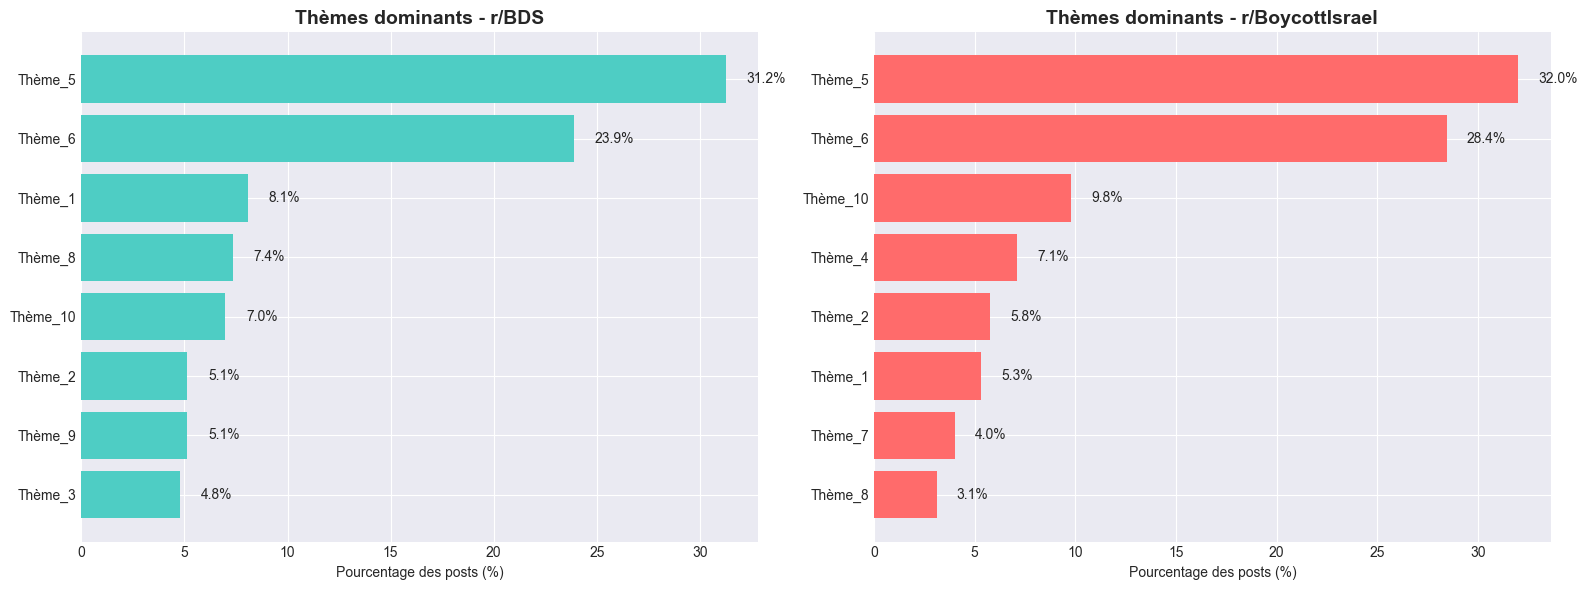

In [38]:
print("\n" + "="*60)
print("ANALYSE DES THÈMES PAR SUBREDDIT")
print("="*60)

# Création d'un dataframe d'analyse
topic_analysis = []

for subreddit in df_filtered['subreddit'].unique():
    sub_df = df_filtered[df_filtered['subreddit'] == subreddit]
    
    for topic_id in range(n_topics_final):
        topic_posts = sub_df[sub_df['dominant_topic'] == topic_id]
        topic_name = f"Thème_{topic_id+1}"
        
        if len(topic_posts) > 0:
            # Exemple de titre représentatif
            sample_title = topic_posts.iloc[0]['title'][:100] + "..." if len(topic_posts.iloc[0]['title']) > 100 else topic_posts.iloc[0]['title']
            
            topic_analysis.append({
                'Subreddit': subreddit,
                'Thème': topic_name,
                'Nombre de posts': len(topic_posts),
                'Pourcentage': len(topic_posts)/len(sub_df)*100,
                'Score moyen': topic_posts['score'].mean(),
                'Titre représentatif': sample_title
            })

topic_df = pd.DataFrame(topic_analysis)
topic_df = topic_df.sort_values(['Subreddit', 'Nombre de posts'], ascending=[True, False])

print("\nDistribution des thèmes par subreddit:")
for subreddit in topic_df['Subreddit'].unique():
    print(f"\n{subreddit}:")
    sub_topics = topic_df[topic_df['Subreddit'] == subreddit].head(5)
    for _, row in sub_topics.iterrows():
        print(f"  {row['Thème']}: {row['Nombre de posts']} posts ({row['Pourcentage']:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, subreddit in enumerate(['BDS', 'BoycottIsrael']):
    sub_data = topic_df[topic_df['Subreddit'] == subreddit].head(8)
    
    axes[idx].barh(sub_data['Thème'], sub_data['Pourcentage'], color='#FF6B6B' if subreddit == 'BoycottIsrael' else '#4ECDC4')
    axes[idx].set_title(f'Thèmes dominants - r/{subreddit}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Pourcentage des posts (%)')
    axes[idx].invert_yaxis()
    
    for i, (_, row) in enumerate(sub_data.iterrows()):
        axes[idx].text(row['Pourcentage'] + 1, i, f"{row['Pourcentage']:.1f}%", va='center')

plt.tight_layout()
plt.savefig('./data/cleaned/themes_par_subreddit.png', dpi=150)
plt.show()

In [39]:
themes_dict = topics.copy()

In [41]:
print("\n" + "="*60)
print("CONSTRUCTION DU RÉSEAU SÉMANTIQUE")
print("="*60)

def build_semantic_network(df, author_col='author', topic_col='dominant_topic', n_topics=10):
    """Construit un réseau sémantique auteurs-thèmes"""
    
    # Créer un graphe bipartite
    G = nx.Graph()
    
    # Ajouter les nœuds auteurs et thèmes
    authors = df[author_col].unique()
    topics = [f"Thème_{i+1}" for i in range(n_topics)]
    
    for author in authors:
        G.add_node(author, type='author', bipartite=0)
    
    for topic in topics:
        G.add_node(topic, type='topic', bipartite=1)
    
    # Compter les posts par auteur par thème
    author_topic_counts = {}
    
    for _, row in df.iterrows():
        author = row[author_col]
        topic = f"Thème_{int(row[topic_col])+1}"
        
        key = (author, topic)
        author_topic_counts[key] = author_topic_counts.get(key, 0) + 1
    
    # Ajouter les arêtes avec poids
    for (author, topic), weight in author_topic_counts.items():
        if author in G and topic in G:
            G.add_edge(author, topic, weight=weight)
    
    print(f"Réseau créé:")
    print(f"  - Nœuds: {G.number_of_nodes()} (auteurs: {len(authors)}, thèmes: {len(topics)})")
    print(f"  - Arêtes: {G.number_of_edges()}")
    
    return G

# Construction du réseau
G = build_semantic_network(df_filtered, n_topics=n_topics_final)

# Séparation des nœuds par type
authors = [n for n, d in G.nodes(data=True) if d['type'] == 'author']
topics = [n for n, d in G.nodes(data=True) if d['type'] == 'topic']

print(f"\nAuteurs dans le réseau: {len(authors)}")
print(f"Thèmes dans le réseau: {len(topics)}")


CONSTRUCTION DU RÉSEAU SÉMANTIQUE
Réseau créé:
  - Nœuds: 264 (auteurs: 254, thèmes: 10)
  - Arêtes: 355

Auteurs dans le réseau: 254
Thèmes dans le réseau: 10


In [42]:
print("\n" + "="*60)
print("CALCUL DES MÉTRIQUES DE CENTRALITÉ")
print("="*60)

def calculate_centrality_metrics(G, authors_list):
    """Calcule les métriques de centralité pour les auteurs"""
    
    # Créer un sous-graphe projection pour les auteurs (réseau unipartite)
    # Méthode: Deux auteurs sont connectés s'ils écrivent sur les mêmes thèmes
    
    # Matrice auteur-thème
    author_topic_matrix = {}
    
    for author in authors_list:
        # Récupérer les thèmes auxquels l'auteur est connecté
        connected_topics = [n for n in G.neighbors(author) if n.startswith('Thème_')]
        author_topic_matrix[author] = set(connected_topics)
    
    # Créer un nouveau graphe pour les auteurs
    G_authors = nx.Graph()
    
    # Ajouter les auteurs comme nœuds
    for author in authors_list:
        G_authors.add_node(author)
    
    # Ajouter les arêtes basées sur la similarité de thèmes
    authors = list(authors_list)
    
    for i in range(len(authors)):
        for j in range(i+1, len(authors)):
            author1 = authors[i]
            author2 = authors[j]
            
            topics1 = author_topic_matrix[author1]
            topics2 = author_topic_matrix[author2]
            
            # Similarité de Jaccard
            if topics1 and topics2:
                intersection = len(topics1.intersection(topics2))
                union = len(topics1.union(topics2))
                
                if union > 0:
                    similarity = intersection / union
                    
                    # Ajouter une arête si similarité significative
                    if similarity > 0.2:  # Seuil ajustable
                        G_authors.add_edge(author1, author2, weight=similarity)
    
    print(f"\nRéseau auteurs-auteurs créé:")
    print(f"  - Nœuds: {G_authors.number_of_nodes()}")
    print(f"  - Arêtes: {G_authors.number_of_edges()}")
    print(f"  - Densité: {nx.density(G_authors):.4f}")
    
    # Calcul des métriques de centralité
    print("\nCalcul des métriques de centralité...")
    
    centrality_metrics = {}
    
    # 1. Degree Centrality
    degree_cent = nx.degree_centrality(G_authors)
    
    # 2. Betweenness Centrality
    betweenness_cent = nx.betweenness_centrality(G_authors, weight='weight')
    
    # 3. Closeness Centrality
    closeness_cent = nx.closeness_centrality(G_authors)
    
    # 4. Eigenvector Centrality
    try:
        eigenvector_cent = nx.eigenvector_centrality(G_authors, max_iter=1000, weight='weight')
    except:
        eigenvector_cent = {node: 0 for node in G_authors.nodes()}
    
    # 5. PageRank
    pagerank = nx.pagerank(G_authors, weight='weight')
    
    # Compilation des résultats
    for author in authors_list:
        if author in G_authors:
            centrality_metrics[author] = {
                'degree': degree_cent.get(author, 0),
                'betweenness': betweenness_cent.get(author, 0),
                'closeness': closeness_cent.get(author, 0),
                'eigenvector': eigenvector_cent.get(author, 0),
                'pagerank': pagerank.get(author, 0),
                'num_topics': len(author_topic_matrix[author]),
                'num_posts': len(df_filtered[df_filtered['author'] == author])
            }
    
    return G_authors, centrality_metrics

# Calcul des métriques
G_authors, centrality_metrics = calculate_centrality_metrics(G, authors)

# Création d'un dataframe avec les résultats
centrality_df = pd.DataFrame.from_dict(centrality_metrics, orient='index')
centrality_df = centrality_df.sort_values('degree', ascending=False)

print(f"\nTop 10 auteurs par centralité:")
print(centrality_df.head(10).round(4))


CALCUL DES MÉTRIQUES DE CENTRALITÉ

Réseau auteurs-auteurs créé:
  - Nœuds: 254
  - Arêtes: 9414
  - Densité: 0.2930

Calcul des métriques de centralité...

Top 10 auteurs par centralité:
                     degree  betweenness  closeness  eigenvector  pagerank  \
KingofTrilobites123  0.7352       0.0298     0.7906       0.0428    0.0049   
Ilovedia             0.7312       0.1239     0.7882       0.0326    0.0044   
KnowTheTruthMatters  0.7312       0.1239     0.7882       0.0326    0.0044   
Able_Compote6571     0.7115       0.1125     0.7761       0.0316    0.0043   
CopiousCool          0.6996       0.0219     0.7690       0.0436    0.0047   
90stvkid             0.6996       0.0192     0.7690       0.0426    0.0047   
Particular_Log_3594  0.6759       0.0845     0.7552       0.0317    0.0041   
Financial_Smile4143  0.6601       0.0956     0.7463       0.0309    0.0041   
adilbuilds           0.6561       0.0907     0.7441       0.0319    0.0038   
YamFrosty6169        0.6522    

In [16]:
import community.community_louvain as community_louvain

print("\n" + "="*60)
print("DÉTECTION DE COMMUNAUTÉS")
print("="*60)

def detect_communities(G_authors):
    """Détecte les communautés avec l'algorithme de Louvain"""
    
    # Assurer que le graphe est non dirigé et connexe
    if not nx.is_connected(G_authors):
        # Prendre la plus grande composante connexe
        largest_cc = max(nx.connected_components(G_authors), key=len)
        G_main = G_authors.subgraph(largest_cc).copy()
        print(f"Utilisation de la plus grande composante connexe: {G_main.number_of_nodes()} nœuds")
    else:
        G_main = G_authors
    
    # Détection de communautés
    partition = community_louvain.best_partition(G_main, weight='weight', resolution=1.0)
    
    # Statistiques des communautés
    communities = {}
    for node, comm_id in partition.items():
        communities.setdefault(comm_id, []).append(node)
    
    print(f"\nNombre de communautés détectées: {len(communities)}")
    
    # Taille des communautés
    community_sizes = {comm_id: len(nodes) for comm_id, nodes in communities.items()}
    
    print("\nTaille des communautés:")
    for comm_id, size in sorted(community_sizes.items(), key=lambda x: x[1], reverse=True):
        print(f"  Communauté {comm_id}: {size} membres")
    
    # Caractérisation des communautés
    print("\nCaractérisation des communautés:")
    
    for comm_id, members in communities.items():
        if len(members) >= 3:  # Seulement les communautés significatives
            # Analyser les thèmes préférés de cette communauté
            community_topics = []
            
            for author in members:
                author_topics = [n for n in G.neighbors(author) if n.startswith('Thème_')]
                community_topics.extend(author_topics)
            
            if community_topics:
                topic_counter = Counter(community_topics)
                top_topics = topic_counter.most_common(3)
                
                print(f"\nCommunauté {comm_id} ({len(members)} membres):")
                for topic, count in top_topics:
                    print(f"  - {topic}: {count} mentions")
    
    return partition, communities

# Détection des communautés
partition, communities = detect_communities(G_authors)

# Ajout des communautés au dataframe de centralité
centrality_df['community'] = centrality_df.index.map(lambda x: partition.get(x, -1))


DÉTECTION DE COMMUNAUTÉS

Nombre de communautés détectées: 7

Taille des communautés:
  Communauté 2: 92 membres
  Communauté 0: 75 membres
  Communauté 6: 29 membres
  Communauté 5: 27 membres
  Communauté 3: 24 membres
  Communauté 4: 4 membres
  Communauté 1: 3 membres

Caractérisation des communautés:

Communauté 0 (75 membres):
  - Thème_6: 75 mentions
  - Thème_5: 22 mentions
  - Thème_1: 10 mentions

Communauté 6 (29 membres):
  - Thème_2: 12 mentions
  - Thème_1: 11 mentions
  - Thème_7: 8 mentions

Communauté 2 (92 membres):
  - Thème_5: 92 mentions
  - Thème_1: 4 mentions
  - Thème_9: 3 mentions

Communauté 3 (24 membres):
  - Thème_10: 24 mentions
  - Thème_8: 1 mentions
  - Thème_2: 1 mentions

Communauté 5 (27 membres):
  - Thème_4: 16 mentions
  - Thème_8: 12 mentions
  - Thème_1: 1 mentions

Communauté 1 (3 membres):
  - Thème_3: 3 mentions

Communauté 4 (4 membres):
  - Thème_9: 4 mentions



VISUALISATION DU RÉSEAU
Réseau à visualiser: 254 nœuds, 9414 arêtes


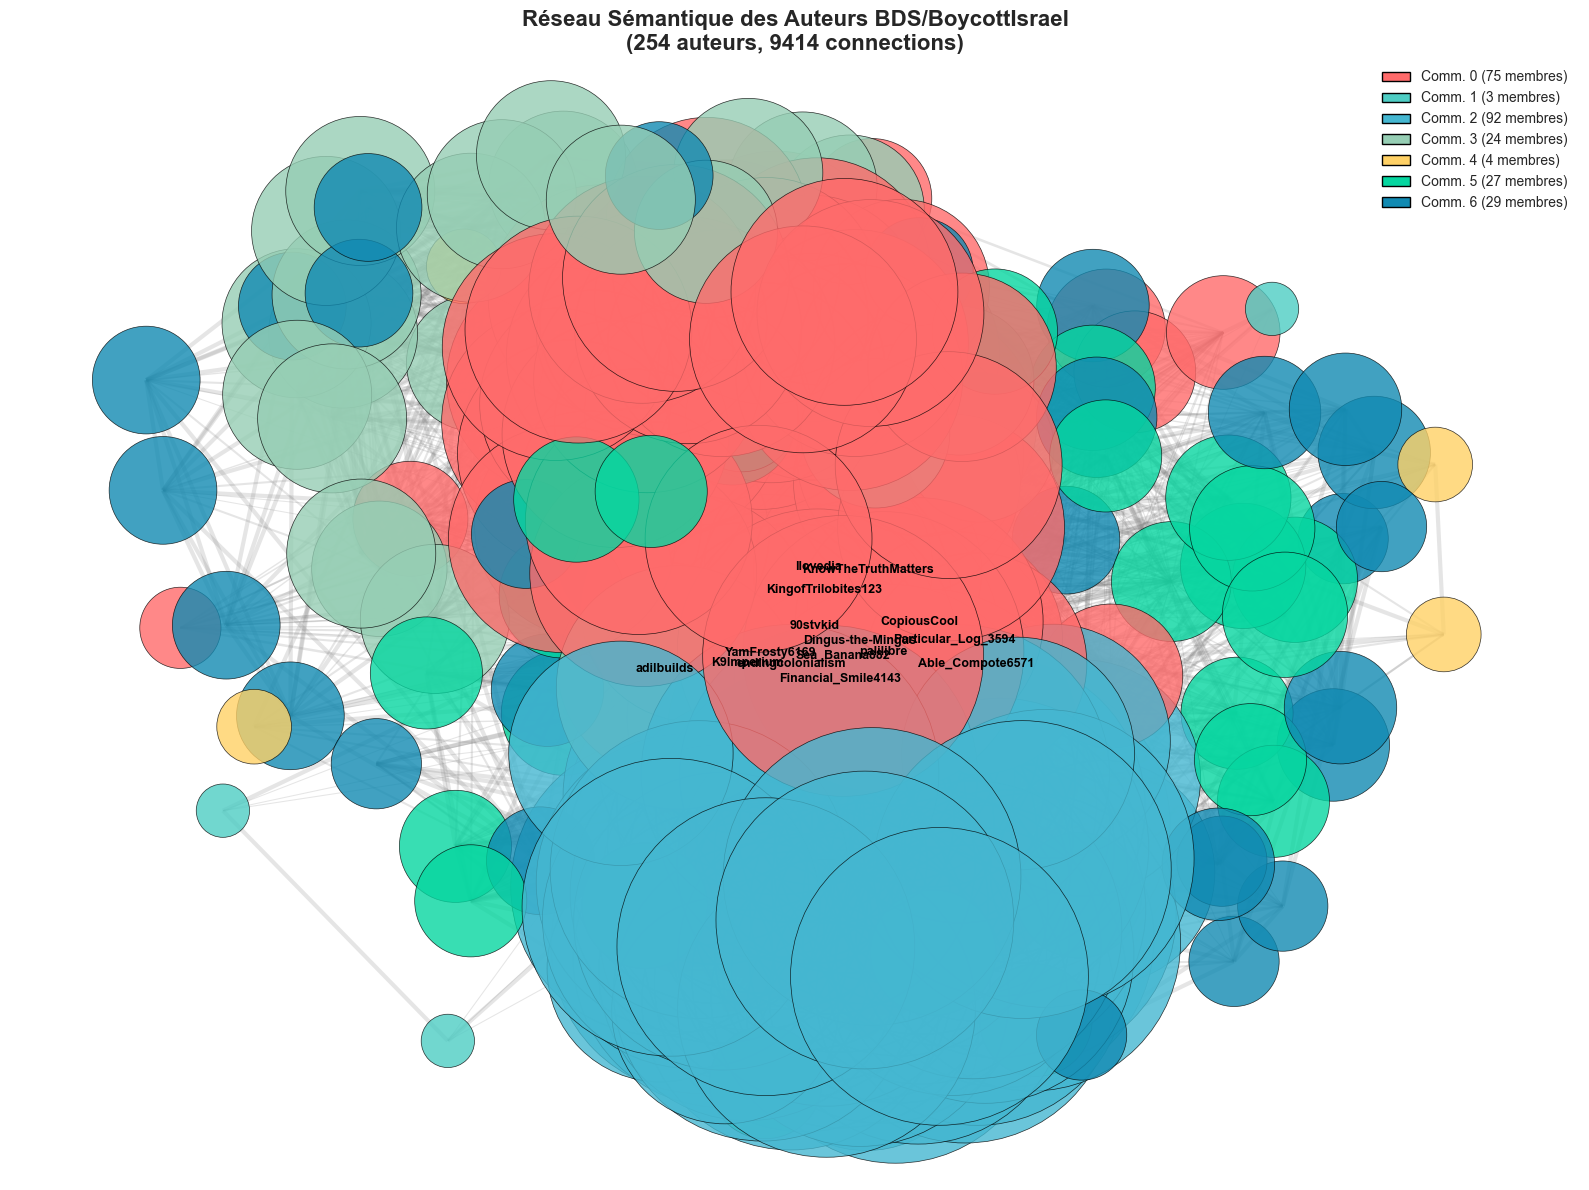


Visualisation sauvegardée: ./data/cleaned/reseau_semantique.png


In [43]:
print("\n" + "="*60)
print("VISUALISATION DU RÉSEAU")
print("="*60)

def visualize_network(G_authors, centrality_df, partition, output_path='./data/cleaned/'):
    """Visualise le réseau d'auteurs"""
    
    # Utiliser seulement la plus grande composante connexe
    if not nx.is_connected(G_authors):
        largest_cc = max(nx.connected_components(G_authors), key=len)
        G_viz = G_authors.subgraph(largest_cc).copy()
    else:
        G_viz = G_authors
    
    print(f"Réseau à visualiser: {G_viz.number_of_nodes()} nœuds, {G_viz.number_of_edges()} arêtes")
    
    # Configuration de la visualisation
    plt.figure(figsize=(16, 12))
    
    # Position des nœuds (layout)
    pos = nx.spring_layout(G_viz, k=1, iterations=50, weight='weight', seed=42)
    
    # Taille des nœuds basée sur le degree
    node_sizes = []
    for node in G_viz.nodes():
        degree = G_viz.degree(node, weight='weight')
        node_sizes.append(100 + degree * 500)  # Échelle ajustable
    
    # Couleurs basées sur les communautés
    node_colors = []
    for node in G_viz.nodes():
        comm_id = partition.get(node, -1)
        # Palette de couleurs pour les communautés
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFD166', 
                 '#06D6A0', '#118AB2', '#EF476F', '#073B4C', '#7209B7']
        color = colors[comm_id % len(colors)] if comm_id != -1 else '#CCCCCC'
        node_colors.append(color)
    
    # Dessiner le réseau
    nx.draw_networkx_nodes(G_viz, pos, 
                          node_size=node_sizes,
                          node_color=node_colors,
                          alpha=0.8,
                          edgecolors='black',
                          linewidths=0.5)
    
    # Dessiner les arêtes
    edges = G_viz.edges(data=True)
    edge_weights = [d['weight'] * 3 for (u, v, d) in edges]  # Épaisseur proportionnelle au poids
    
    nx.draw_networkx_edges(G_viz, pos,
                          edgelist=edges,
                          width=edge_weights,
                          alpha=0.2,
                          edge_color='gray')
    
    # Étiquettes pour les nœuds importants
    important_nodes = centrality_df.nlargest(15, 'degree').index.tolist()
    labels = {node: node if node in important_nodes else '' for node in G_viz.nodes()}
    
    nx.draw_networkx_labels(G_viz, pos, labels, font_size=9, font_weight='bold')
    
    # Titre et légende
    plt.title('Réseau Sémantique des Auteurs BDS/BoycottIsrael\n'
             f'({G_viz.number_of_nodes()} auteurs, {G_viz.number_of_edges()} connections)', 
             fontsize=16, fontweight='bold')
    
    # Légende pour les communautés
    from matplotlib.patches import Patch
    
    legend_elements = []
    unique_communities = sorted(set(partition.values()))
    
    for comm_id in unique_communities[:8]:  # Limiter à 8 communautés pour la lisibilité
        if comm_id != -1:
            member_count = len([n for n in G_viz.nodes() if partition.get(n) == comm_id])
            if member_count >= 3:
                color = colors[comm_id % len(colors)]
                legend_elements.append(
                    Patch(facecolor=color, edgecolor='black', 
                         label=f'Comm. {comm_id} ({member_count} membres)')
                )
    
    if legend_elements:
        plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    plt.axis('off')
    plt.tight_layout()
    
    # Sauvegarde
    output_file = output_path + 'reseau_semantique.png'
    plt.savefig(output_file, dpi=200, bbox_inches='tight')
    plt.show()
    
    print(f"\nVisualisation sauvegardée: {output_file}")
    
    return G_viz

# Générer la visualisation
G_viz = visualize_network(G_authors, centrality_df, partition)

In [51]:
print("\n" + "="*60)
print("EXPORT POUR GEPHI")
print("="*60)

def export_for_gephi(G_authors, centrality_df, partition, topics_dict, output_path='./data/cleaned/'):
    """Exporte les données pour Gephi"""
    
    # Calculer le degré normalisé
    degree_centrality = nx.degree_centrality(G_authors)
    
    # 1. Fichier des nœuds (auteurs)
    nodes_data = []
    
    for author in G_authors.nodes():
        # Récupérer les informations de l'auteur
        author_info = centrality_df.loc[author] if author in centrality_df.index else None
        
        # Récupérer les thèmes de l'auteur
        author_topics = []
        if author in G.nodes():
            author_topics = [n for n in G.neighbors(author) if n.startswith('Thème_')]
        
        # Compter les posts par subreddit
        author_posts = df_filtered[df_filtered['author'] == author]
        bds_posts = len(author_posts[author_posts['subreddit'] == 'BDS'])
        boycott_posts = len(author_posts[author_posts['subreddit'] == 'BoycottIsrael'])
        
        node_data = {
            'Id': author,
            'Label': author,
            'Type': 'Auteur',
            'Community': partition.get(author, -1),
            'Degree': degree_centrality.get(author, 0),  # CHANGÉ ICI : normalisé (0-1)
            'DegreeWeighted': G_authors.degree(author, weight='weight'),  # Ancien degré pondéré
            'Betweenness': author_info['betweenness'] if author_info is not None else 0,
            'Closeness': author_info['closeness'] if author_info is not None else 0,
            'Eigenvector': author_info['eigenvector'] if author_info is not None else 0,
            'PageRank': author_info['pagerank'] if author_info is not None else 0,
            'NumTopics': len(author_topics),
            'NumPosts': len(author_posts),
            'BDS_Posts': bds_posts,
            'BoycottIsrael_Posts': boycott_posts,
            'PrimarySubreddit': 'BDS' if bds_posts > boycott_posts else 'BoycottIsrael' if boycott_posts > 0 else 'None',
            'Topics': ';'.join(author_topics)
        }
        
        nodes_data.append(node_data)
    
    nodes_df = pd.DataFrame(nodes_data)
    nodes_file = output_path + 'gephi_nodes.csv'
    nodes_df.to_csv(nodes_file, index=False, encoding='utf-8')
    print(f"✓ Fichier des nœuds exporté: {nodes_file}")
    print(f"  - {len(nodes_df)} nœuds exportés")
    
    # 2. Fichier des arêtes (connections entre auteurs)
    edges_data = []
    
    for u, v, data in G_authors.edges(data=True):
        edge_data = {
            'Source': u,
            'Target': v,
            'Type': 'Undirected',
            'Weight': data.get('weight', 1.0),
            'Similarity': data.get('weight', 1.0)
        }
        edges_data.append(edge_data)
    
    edges_df = pd.DataFrame(edges_data)
    edges_file = output_path + 'gephi_edges.csv'
    edges_df.to_csv(edges_file, index=False)
    print(f"✓ Fichier des arêtes exporté: {edges_file}")
    print(f"  - {len(edges_df)} arêtes exportées")
    
    # 3. Fichier des thèmes
    themes_data = []
    
    for topic_id, topic_words in topics_dict.items():
        theme_data = {
            'Theme_Id': topic_id,
            'Theme_Name': topic_id,
            'Top_Words': ', '.join(topic_words),
            'Num_Authors': len([n for n in G.neighbors(topic_id) if G.nodes[n]['type'] == 'author']),
            'Num_Posts': len(df_filtered[df_filtered['dominant_topic'] == int(topic_id.split('_')[1]) - 1])
        }
        themes_data.append(theme_data)
    
    themes_df = pd.DataFrame(themes_data)
    themes_file = output_path + 'gephi_themes.csv'
    themes_df.to_csv(themes_file, index=False)
    print(f"✓ Fichier des thèmes exporté: {themes_file}")
    
    # Afficher vérification
    print(f"\nVérification de la normalisation:")
    print(f"- Degree max: {nodes_df['Degree'].max():.4f} (doit être ≤ 1.0)")
    print(f"- Degree min: {nodes_df['Degree'].min():.4f} (doit être ≥ 0.0)")
    print(f"- Degree moyen: {nodes_df['Degree'].mean():.4f}")
    
    return nodes_df, edges_df, themes_df

# Export pour Gephi
nodes_df, edges_df, themes_df = export_for_gephi(G_authors, centrality_df, partition, themes_dict)


EXPORT POUR GEPHI
✓ Fichier des nœuds exporté: ./data/cleaned/gephi_nodes.csv
  - 254 nœuds exportés
✓ Fichier des arêtes exporté: ./data/cleaned/gephi_edges.csv
  - 9414 arêtes exportées
✓ Fichier des thèmes exporté: ./data/cleaned/gephi_themes.csv

Vérification de la normalisation:
- Degree max: 0.7352 (doit être ≤ 1.0)
- Degree min: 0.0198 (doit être ≥ 0.0)
- Degree moyen: 0.2930


In [52]:
print("\n" + "="*60)
print("ANALYSE DES RÉSULTATS")
print("="*60)

def analyze_results(centrality_df, G_authors, partition):
    """Analyse approfondie des résultats du réseau"""
    
    print("1. STRUCTURE DU RÉSEAU:")
    print(f"   - Densité: {nx.density(G_authors):.4f}")
    print(f"   - Diamètre: {nx.diameter(G_authors) if nx.is_connected(G_authors) else 'Non connexe'}")
    print(f"   - Coefficient de clustering moyen: {nx.average_clustering(G_authors):.3f}")
    
    print("\n2. ACTEURS CLÉS:")
    
    # Auteurs les plus centraux par métrique
    metrics = ['degree', 'betweenness', 'closeness', 'eigenvector', 'pagerank']
    
    for metric in metrics:
        top_authors = centrality_df.nlargest(3, metric)
        print(f"\n   Top 3 par {metric}:")
        for author, row in top_authors.iterrows():
            print(f"   - {author}: {row[metric]:.4f} "
                  f"(posts: {row['num_posts']}, thèmes: {row['num_topics']})")
    
    print("\n3. CARACTÉRISTIQUES DES COMMUNAUTÉS:")
    
    # Analyse par communauté
    for comm_id in sorted(set(partition.values())):
        if comm_id != -1:
            members = [node for node in partition if partition[node] == comm_id]
            if len(members) >= 3:
                # Caractérisation de la communauté
                comm_df = centrality_df[centrality_df.index.isin(members)]
                
                print(f"\n   Communauté {comm_id} ({len(members)} membres):")
                print(f"   - Score moyen: {comm_df['num_posts'].mean():.1f} posts/membre")
                print(f"   - Thèmes moyens: {comm_df['num_topics'].mean():.1f}/membre")
                print(f"   - Centralité moyenne: {comm_df['degree'].mean():.4f}")
                
                # Top contributeurs
                top_contrib = comm_df.nlargest(2, 'num_posts')
                if len(top_contrib) > 0:
                    print(f"   - Top contributeur: {top_contrib.index[0]} "
                          f"({top_contrib.iloc[0]['num_posts']} posts)")
    
    print("\n4. COMPARAISON BDS vs BOYCOTTISRAEL:")
    
    # Ajouter l'information du subreddit principal
    centrality_df['primary_subreddit'] = centrality_df.apply(
        lambda row: 'BDS' if row.get('BDS_Posts', 0) > row.get('BoycottIsrael_Posts', 0) 
        else 'BoycottIsrael' if row.get('BoycottIsrael_Posts', 0) > 0 else 'Mixed',
        axis=1
    )
    
    for subreddit in ['BDS', 'BoycottIsrael', 'Mixed']:
        sub_df = centrality_df[centrality_df['primary_subreddit'] == subreddit]
        if len(sub_df) > 0:
            print(f"\n   {subreddit} ({len(sub_df)} auteurs):")
            print(f"   - Centralité moyenne: {sub_df['degree'].mean():.4f}")
            print(f"   - Posts moyens: {sub_df['num_posts'].mean():.1f}")
            print(f"   - Thèmes moyens: {sub_df['num_topics'].mean():.1f}")

# Analyse des résultats
analyze_results(centrality_df, G_authors, partition)


ANALYSE DES RÉSULTATS
1. STRUCTURE DU RÉSEAU:
   - Densité: 0.2930
   - Diamètre: 3
   - Coefficient de clustering moyen: 0.907

2. ACTEURS CLÉS:

   Top 3 par degree:
   - KingofTrilobites123: 0.7352 (posts: 3, thèmes: 3)
   - Ilovedia: 0.7312 (posts: 7, thèmes: 4)
   - KnowTheTruthMatters: 0.7312 (posts: 5, thèmes: 4)

   Top 3 par betweenness:
   - Ilovedia: 0.1239 (posts: 7, thèmes: 4)
   - KnowTheTruthMatters: 0.1239 (posts: 5, thèmes: 4)
   - Able_Compote6571: 0.1125 (posts: 12, thèmes: 4)

   Top 3 par closeness:
   - KingofTrilobites123: 0.7906 (posts: 3, thèmes: 3)
   - Ilovedia: 0.7882 (posts: 7, thèmes: 4)
   - KnowTheTruthMatters: 0.7882 (posts: 5, thèmes: 4)

   Top 3 par eigenvector:
   - VolkswagenPanda: 0.1070 (posts: 1, thèmes: 1)
   - dark00H: 0.1070 (posts: 2, thèmes: 1)
   - veinsouls: 0.1070 (posts: 1, thèmes: 1)

   Top 3 par pagerank:
   - YamFrosty6169: 0.0053 (posts: 4, thèmes: 2)
   - palilibre: 0.0053 (posts: 2, thèmes: 2)
   - K9Imperium: 0.0053 (posts: 2, 

In [53]:
print("\n" + "="*60)
print("SAUVEGARDE DES RÉSULTATS")
print("="*60)

# 1. Sauvegarde du dataframe de centralité
centrality_file = './data/cleaned/centrality_analysis.csv'
centrality_df.to_csv(centrality_file, encoding='utf-8')
print(f"✓ Analyse de centralité sauvegardée: {centrality_file}")

# 2. Sauvegarde des thèmes
themes_export = pd.DataFrame([
    {'theme_id': k, 'top_words': ', '.join(v), 'description': f"Thème {k.split('_')[1]}"}
    for k, v in themes_dict.items()
])
themes_export.to_csv('./data/cleaned/themes_description.csv', index=False)
print(f"✓ Description des thèmes sauvegardée")

# 3. Sauvegarde des données enrichies avec thèmes
df_enriched = df_filtered.copy()
df_enriched['topic_name'] = df_enriched['dominant_topic'].apply(lambda x: f"Thème_{x+1}")
df_enriched['top_words'] = df_enriched['dominant_topic'].apply(
    lambda x: ', '.join(themes_dict.get(f"Thème_{x+1}", [])) if x >= 0 else ''
)
df_enriched.to_csv('./data/cleaned/posts_with_topics.csv', index=False)
print(f"✓ Posts avec thèmes sauvegardés")

# 4. Rapport d'analyse
with open('./data/cleaned/network_analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("RAPPORT D'ANALYSE DU RÉSEAU SÉMANTIQUE\n")
    f.write("="*60 + "\n\n")
    
    f.write("1. SYNTHÈSE GÉNÉRALE\n")
    f.write(f"   - Posts analysés: {len(df_filtered)}\n")
    f.write(f"   - Auteurs uniques: {len(authors)}\n")
    f.write(f"   - Thèmes identifiés: {n_topics_final}\n")
    f.write(f"   - Arêtes dans le réseau: {G_authors.number_of_edges()}\n")
    f.write(f"   - Communautés détectées: {len(set(partition.values()))}\n\n")
    
    f.write("2. THÈMES PRINCIPAUX\n")
    for theme_id, words in themes_dict.items():
        f.write(f"   {theme_id}: {', '.join(words[:5])}\n")
    
    f.write("\n3. ACTEURS INFLUENTS\n")
    top_influencers = centrality_df.nlargest(10, 'degree')
    for i, (author, row) in enumerate(top_influencers.iterrows(), 1):
        f.write(f"   {i}. {author}: Degree={row['degree']:.3f}, "
                f"Posts={row['num_posts']}, Thèmes={row['num_topics']}\n")

print("✓ Rapport d'analyse généré")



SAUVEGARDE DES RÉSULTATS
✓ Analyse de centralité sauvegardée: ./data/cleaned/centrality_analysis.csv
✓ Description des thèmes sauvegardée
✓ Posts avec thèmes sauvegardés
✓ Rapport d'analyse généré


In [54]:
print(themes_dict)

{'Thème_1': ['gaza', 'child', 'israel', 'christian', 'hamas', 'genocide', 'fighter', 'saying', 'based', 'carrying'], 'Thème_2': ['music', 'phone', 'celebrity', 'streaming', 'protesting', 'alternative', 'israel', 'spotify', 'ask', 'watch'], 'Thème_3': ['terrible', 'gadot', 'appeal', 'gal', 'anti', 'youtube', 'bd', 'amp', 'gaza', 'iran'], 'Thème_4': ['boycott', 'movie', 'list', 'apps', 'brand', 'malaysia', 'linked', 'reshaped', 'looking', 'industry'], 'Thème_5': ['palestine', 'boycott', 'time', 'israel', 'want', 'free', 'medium', 'gaza', 'pro', 'family'], 'Thème_6': ['israel', 'boycott', 'zionist', 'israeli', 'palestinian', 'company', 'boycotting', 'starbucks', 'show', 'eurovision'], 'Thème_7': ['mcdonald', 'country', 'cola', 'coca', 'israel', 'better', 'working', 'able', 'lie', 'fuck'], 'Thème_8': ['card', 'gift', 'jewish', 'shoe', 'gaza', 'journalist', 'holiday', 'month', 'killing', 'strawberry'], 'Thème_9': ['alternative', 'best', 'amazon', 'store', 'power', 'thanks', 'genocide', 'eth

In [55]:
print("="*60)
print("📊 STATISTIQUES GÉNÉRALES DU RÉSEAU")
print("="*60)
print(f"Nombre total d'auteurs dans le réseau: {G_authors.number_of_nodes()}")
print(f"Nombre total de connections: {G_authors.number_of_edges()}")
print(f"Densité du réseau: {nx.density(G_authors):.4f}")
print(f"Coefficient de clustering moyen: {nx.average_clustering(G_authors):.3f}")
print(f"Est-ce que le réseau est connexe? {nx.is_connected(G_authors)}")

if not nx.is_connected(G_authors):
    components = list(nx.connected_components(G_authors))
    print(f"Nombre de composantes connexes: {len(components)}")
    print(f"Taille de la plus grande composante: {len(max(components, key=len))}")
    
print("\n" + "="*60)
print("👑 TOP 10 DES AUTEURS LES PLUS INFLUENTS")
print("="*60)
print("Classement par Degree Centrality (connectivité):")
top_10_degree = centrality_df.nlargest(10, 'degree')[['degree', 'num_posts', 'num_topics']]
print(top_10_degree.round(4))

print("\nTop 3 par Betweenness (ponts entre communautés):")
top_3_betweenness = centrality_df.nlargest(3, 'betweenness')[['betweenness', 'degree']]
print(top_3_betweenness.round(4))

print("\n" + "="*60)
print("🏘️ ANALYSE DES COMMUNAUTÉS DÉTECTÉES")
print("="*60)

# Compter les membres par communauté
comm_counts = {}
for node, comm_id in partition.items():
    comm_counts[comm_id] = comm_counts.get(comm_id, 0) + 1

print(f"Nombre total de communautés: {len(comm_counts)}")
print("\nTaille des communautés (tri décroissant):")
for comm_id, size in sorted(comm_counts.items(), key=lambda x: x[1], reverse=True):
    if size >= 3:  # Seulement communautés significatives
        print(f"  Communauté {comm_id}: {size} membres")

# Voir la distribution
print(f"\nDistribution:")
print(f"  - Communautés avec 1-2 membres: {sum(1 for s in comm_counts.values() if s <= 2)}")
print(f"  - Communautés avec 3-5 membres: {sum(1 for s in comm_counts.values() if 3 <= s <= 5)}")
print(f"  - Communautés avec 6+ membres: {sum(1 for s in comm_counts.values() if s >= 6)}")

print("\n" + "="*60)
print("🎯 DESCRIPTION DES THÈMES PRINCIPAUX")
print("="*60)

# Afficher les 5-6 thèmes les plus importants
print("Thèmes identifiés avec leurs mots-clés:")
for i, (theme_id, words) in enumerate(list(themes_dict.items())[:6]):
    print(f"\n{theme_id}:")
    print(f"  Mots-clés: {', '.join(words[:8])}")
    
    # Compter combien d'auteurs parlent de ce thème
    theme_authors = []
    for author in G_authors.nodes():
        if f"Thème_{i+1}" in G.neighbors(author):
            theme_authors.append(author)
    
    print(f"  Auteurs concernés: {len(theme_authors)}")
    
    # Voir la répartition par subreddit
    if len(theme_authors) > 0:
        author_posts = df_filtered[df_filtered['author'].isin(theme_authors)]
        bds_count = len(author_posts[author_posts['subreddit'] == 'BDS'])
        boycott_count = len(author_posts[author_posts['subreddit'] == 'BoycottIsrael'])
        print(f"  Répartition: BDS={bds_count}, BoycottIsrael={boycott_count}")



📊 STATISTIQUES GÉNÉRALES DU RÉSEAU
Nombre total d'auteurs dans le réseau: 254
Nombre total de connections: 9414
Densité du réseau: 0.2930
Coefficient de clustering moyen: 0.907
Est-ce que le réseau est connexe? True

👑 TOP 10 DES AUTEURS LES PLUS INFLUENTS
Classement par Degree Centrality (connectivité):
                     degree  num_posts  num_topics
KingofTrilobites123  0.7352          3           3
Ilovedia             0.7312          7           4
KnowTheTruthMatters  0.7312          5           4
Able_Compote6571     0.7115         12           4
CopiousCool          0.6996          5           3
90stvkid             0.6996          3           3
Particular_Log_3594  0.6759          4           4
Financial_Smile4143  0.6601          8           4
adilbuilds           0.6561          8           4
YamFrosty6169        0.6522          4           2

Top 3 par Betweenness (ponts entre communautés):
                     betweenness  degree
Ilovedia                  0.1239  0.7312
K

In [59]:
import pandas as pd
import numpy as np
import math

def enrich_nodes_with_roles(nodes_df, edges_df=None, topics_dict=None):
    """
    Enrichit le dataframe des nœuds avec toutes les colonnes de rôles
    
    Parameters:
    nodes_df: DataFrame des nœuds (gephi_nodes.csv)
    edges_df: DataFrame des arêtes (optionnel, pour calculs avancés)
    topics_dict: Dictionnaire des thèmes (optionnel)
    
    Returns:
    DataFrame enrichi
    """
    
    print("📊 Enrichissement des données avec les rôles...")
    
    # Copie pour éviter les modifications inplace
    df = nodes_df.copy()
    
    # Assurer les types numériques
    numeric_cols = ['Degree', 'Betweenness', 'Closeness', 'Eigenvector', 
                    'PageRank', 'NumTopics', 'NumPosts', 'BDS_Posts', 
                    'BoycottIsrael_Posts']
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # --------------------------------------------------------
    # 1. CATÉGORIES BINAIRES (Boolean)
    # --------------------------------------------------------
    print("  → Création des catégories binaires...")
    
    df['is_hub'] = df['Degree'] > 0.7
    df['is_broker'] = df['Betweenness'] > 0.1
    df['is_contributor'] = df['NumPosts'] > 10
    df['is_specialist'] = (df['NumTopics'] >= 2) & (df['NumTopics'] <= 3)
    df['is_active'] = df['NumPosts'] >= 5
    df['is_multitopic'] = df['NumTopics'] >= 4
    df['is_crossposter'] = (df['BDS_Posts'] > 0) & (df['BoycottIsrael_Posts'] > 0)
    df['is_influencer'] = (df['Degree'] > 0.6) & (df['Betweenness'] > 0.05)
    
    # --------------------------------------------------------
    # 2. CATÉGORIES DE RÔLES PRINCIPAUX (String)
    # --------------------------------------------------------
    print("  → Attribution des rôles principaux...")
    
    def assign_role_category(row):
        """Détermine la catégorie principale du rôle"""
        if row['Degree'] > 0.7 and row['Betweenness'] > 0.1:
            return 'Hub-Broker'
        elif row['Degree'] > 0.7:
            return 'Hub'
        elif row['Betweenness'] > 0.1:
            return 'Broker'
        elif row['NumPosts'] > 10:
            return 'Contributor'
        elif 2 <= row['NumTopics'] <= 3:
            return 'Specialist'
        else:
            return 'Regular'
    
    df['role_category'] = df.apply(assign_role_category, axis=1)
    
    # Rôle complet (plus détaillé)
    def assign_role_complete(row):
        """Rôle détaillé combinant plusieurs aspects"""
        roles = []
        
        if row['Degree'] > 0.7:
            roles.append('Hub')
        if row['Betweenness'] > 0.1:
            roles.append('Broker')
        if row['NumPosts'] > 10:
            roles.append('Contributor')
        if 2 <= row['NumTopics'] <= 3:
            roles.append('Specialist')
        
        if roles:
            return '-'.join(roles)
        else:
            return 'Regular'
    
    df['role_complete'] = df.apply(assign_role_complete, axis=1)
    
    # --------------------------------------------------------
    # 3. NIVEAUX (Catégoriels ordonnés)
    # --------------------------------------------------------
    print("  → Création des niveaux...")
    
    # Niveau de hub
    df['hub_level'] = pd.cut(df['Degree'], 
                             bins=[0, 0.5, 0.6, 0.7, 1],
                             labels=['Non-hub', 'Semi-hub', 'Hub', 'Super-hub'],
                             include_lowest=True)
    
    # Niveau de broker
    df['broker_level'] = pd.cut(df['Betweenness'],
                                bins=[0, 0.02, 0.05, 0.1, 1],
                                labels=['Non-broker', 'Petit-broker', 'Broker', 'Super-broker'],
                                include_lowest=True)
    
    # Niveau d'activité
    df['activity_level'] = pd.cut(df['NumPosts'],
                                  bins=[0, 2, 5, 15, 100],
                                  labels=['Occasionnel', 'Actif', 'Très actif', 'Super-actif'],
                                  include_lowest=True)
    
    # Niveau thématique
    df['topic_level'] = pd.cut(df['NumTopics'],
                               bins=[0, 1, 2, 3, 5, 10],
                               labels=['Monotopic', 'Bi-topic', 'Tri-topic', 'Multi-topic', 'Omni-topic'],
                               include_lowest=True)
    
    # --------------------------------------------------------
    # 4. SCORES COMPOSITES (Numeric)
    # --------------------------------------------------------
    print("  → Calcul des scores composites...")
    
    # Score de rôle (importance globale)
    df['role_score'] = (
        df['Degree'] * 0.35 + 
        df['Betweenness'] * 0.25 + 
        np.log1p(df['NumPosts']) * 0.20 +
        ((5 - np.minimum(df['NumTopics'], 5)) / 5 * 0.10) +  # Moins de thèmes = plus spécialisé
        df['Closeness'] * 0.10
    )
    
    # Score d'influence
    df['influence_score'] = (df['Degree'] * 0.6 + df['Betweenness'] * 0.4)
    
    # Score de contenu
    df['content_score'] = (np.log1p(df['NumPosts']) * 0.7 + df['NumTopics'] * 0.3)
    
    # Score de pont (bridge)
    df['bridge_score'] = (df['Betweenness'] * 0.5 + df['Closeness'] * 0.3 + df['Eigenvector'] * 0.2)
    
    # Score d'engagement (combine tout)
    df['engagement_score'] = (
        df['role_score'] * 0.4 +
        np.log1p(df['NumPosts']) * 0.3 +
        df['NumTopics'] * 0.2 +
        (df['BDS_Posts'] + df['BoycottIsrael_Posts']) / df['NumPosts'] * 0.1
    )
    
    # --------------------------------------------------------
    # 5. VISUALISATION (Symboles, couleurs, formes)
    # --------------------------------------------------------
    print("  → Préparation pour la visualisation...")
    
    # Symboles Unicode
    def get_label_symbol(row):
        if row['Degree'] > 0.7:
            return '⬤'  # Cercle plein
        elif row['Betweenness'] > 0.1:
            return '◻'  # Carré
        elif row['NumPosts'] > 10:
            return '▲'  # Triangle
        elif 2 <= row['NumTopics'] <= 3:
            return '⬢'  # Hexagone
        else:
            return '○'  # Cercle vide
    
    df['label_symbol'] = df.apply(get_label_symbol, axis=1)
    
    # Couleurs hexadécimales
    def get_label_color(row):
        if row['Degree'] > 0.7:
            return '#FF0000'  # Rouge
        elif row['Betweenness'] > 0.1:
            return '#FFFF00'  # Jaune
        elif row['NumPosts'] > 10:
            return '#00FF00'  # Vert
        elif 2 <= row['NumTopics'] <= 3:
            return '#0000FF'  # Bleu
        else:
            return '#CCCCCC'  # Gris
    
    df['label_color'] = df.apply(get_label_color, axis=1)
    
    # Formes pour Gephi (circle, square, triangle, diamond)
    def get_node_shape(row):
        if row['Degree'] > 0.7:
            return 'circle'
        elif row['Betweenness'] > 0.1:
            return 'square'
        elif row['NumPosts'] > 10:
            return 'triangle'
        elif 2 <= row['NumTopics'] <= 3:
            return 'diamond'
        else:
            return 'circle'
    
    df['node_shape'] = df.apply(get_node_shape, axis=1)
    
    # Taille suggérée
    df['node_size'] = pd.cut(df['Degree'],
                            bins=[0, 0.3, 0.5, 0.7, 1],
                            labels=['XS', 'S', 'M', 'L'],
                            include_lowest=True)
    
    # --------------------------------------------------------
    # 6. ANALYSE THÉMATIQUE AVANCÉE
    # --------------------------------------------------------
    if 'Topics' in df.columns :
        print("  → Analyse thématique avancée...")
        
        # Extraire le thème principal (premier dans la liste)
        df['primary_topic'] = df['Topics'].apply(
            lambda x: x.split(';')[0] if isinstance(x, str) and ';' in x else 'Unknown'
        )
        
        # Nombre de thèmes uniques
        df['unique_topics'] = df['Topics'].apply(
            lambda x: len(set(x.split(';'))) if isinstance(x, str) and ';' in x else 0
        )
        
        # Diversité thématique
        df['topic_diversity'] = pd.cut(df['unique_topics'] / df['NumTopics'],
                                      bins=[0, 0.3, 0.7, 1],
                                      labels=['Faible', 'Moyenne', 'Forte'],
                                      include_lowest=True)
    
    # --------------------------------------------------------
    # 7. ANALYSE SUBREDDIT
    # --------------------------------------------------------
    print("  → Analyse par subreddit...")
    
    # Ratio BDS vs BoycottIsrael
    df['subreddit_ratio'] = df.apply(
        lambda row: row['BDS_Posts'] / row['NumPosts'] if row['NumPosts'] > 0 else 0.5,
        axis=1
    )
    
    # Dominance claire
    df['subreddit_dominance'] = df.apply(
        lambda row: 
            'BDS' if row['subreddit_ratio'] > 0.7 else
            'BoycottIsrael' if row['subreddit_ratio'] < 0.3 else
            'Mixed',
        axis=1
    )
    
    # Spécialisation subreddit
    df['subreddit_specialization'] = pd.cut(df['subreddit_ratio'],
                                           bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
                                           labels=['Extreme-BI', 'Mostly-BI', 'Balanced', 
                                                   'Mostly-BDS', 'Extreme-BDS'])
    
    # --------------------------------------------------------
    # 8. MÉTRIQUES DE RÉSEAU AVANCÉES (si edges_df fourni)
    # --------------------------------------------------------
    if edges_df is not None:
        print("  → Calcul des métriques de réseau avancées...")
        
        # Créer le graphe
        import networkx as nx
        G = nx.Graph()
        
        # Ajouter les nœuds
        for _, row in df.iterrows():
            G.add_node(row['Id'], **row.to_dict())
        
        # Ajouter les arêtes
        for _, row in edges_df.iterrows():
            G.add_edge(row['Source'], row['Target'], weight=row.get('Weight', 1.0))
        
        # Calculer la centralité de vecteur propre locale
        try:
            eigenvector_local = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
            df['eigenvector_local'] = df['Id'].map(eigenvector_local)
        except:
            df['eigenvector_local'] = 0
        
        # Coefficient de clustering local
        clustering = nx.clustering(G, weight='weight')
        df['clustering_coefficient'] = df['Id'].map(clustering)
    
    # --------------------------------------------------------
    # 9. FINALISATION
    # --------------------------------------------------------
    
    # Mettre à jour le label avec symbole
    df['Label'] = df['label_symbol'] + ' ' + df['Id']
    
    # Ajouter une colonne de priorité d'affichage
    df['display_priority'] = df['role_score'].rank(pct=True)
    
    # Réorganiser les colonnes (optionnel mais recommandé)
    column_order = [
        'Id', 'Label', 'Type', 'Community',
        # Centralités
        'Degree', 'Betweenness', 'Closeness', 'Eigenvector', 'PageRank',
        # Activité
        'NumPosts', 'NumTopics', 'BDS_Posts', 'BoycottIsrael_Posts',
        # Rôles binaires
        'is_hub', 'is_broker', 'is_contributor', 'is_specialist',
        'is_active', 'is_multitopic', 'is_crossposter', 'is_influencer',
        # Catégories
        'role_category', 'role_complete',
        # Niveaux
        'hub_level', 'broker_level', 'activity_level', 'topic_level',
        # Scores
        'role_score', 'influence_score', 'content_score', 
        'bridge_score', 'engagement_score',
        # Visualisation
        'label_symbol', 'label_color', 'node_shape', 'node_size',
        # Subreddit
        'PrimarySubreddit', 'subreddit_ratio', 'subreddit_dominance', 
        'subreddit_specialization',
        # Thèmes
        'Topics', 'primary_topic', 'unique_topics', 'topic_diversity',
        # Divers
        'display_priority'
    ]
    
    # Garder seulement les colonnes existantes
    existing_columns = [col for col in column_order if col in df.columns]
    df = df[existing_columns + [col for col in df.columns if col not in column_order]]
    
    print(f"✅ Données enrichies : {df.shape[1]} colonnes créées")
    print(f"   Auteurs avec rôle de Hub : {df['is_hub'].sum()}")
    print(f"   Auteurs avec rôle de Broker : {df['is_broker'].sum()}")
    print(f"   Auteurs avec rôle de Contributor : {df['is_contributor'].sum()}")
    
    return df

# --------------------------------------------------------
# UTILISATION PRATIQUE
# --------------------------------------------------------
def main():
    """Exemple d'utilisation complète"""
    
    # 1. Charger les données
    print("📥 Chargement des données...")
    nodes_df = pd.read_csv('./data/cleaned/gephi_nodes.csv')
    edges_df = pd.read_csv('./data/cleaned/gephi_edges.csv')
    
    # 2. Enrichir les nœuds
    enriched_nodes = enrich_nodes_with_roles(nodes_df, edges_df)
    
    # 3. Sauvegarder
    print("\n💾 Sauvegarde des fichiers enrichis...")
    
    # Fichier principal pour Gephi
    enriched_nodes.to_csv('./data/cleaned/gephi_nodes_enriched.csv', index=False)
    print(f"   → gephi_nodes_enriched.csv ({enriched_nodes.shape[0]} nœuds, {enriched_nodes.shape[1]} colonnes)")
    
    # Fichier simplifié (seulement colonnes essentielles)
    essential_cols = ['Id', 'Label', 'role_category', 'hub_level', 
                     'broker_level', 'Degree', 'Betweenness', 'NumPosts',
                     'Community', 'PrimarySubreddit', 'label_color']
    enriched_nodes[essential_cols].to_csv('./data/cleaned/gephi_nodes_simple.csv', index=False)
    
    # Fichier d'analyse (toutes les données)
    enriched_nodes.to_csv('./data/cleaned/network_analysis_full.csv', index=False)
    
    # 4. Générer un rapport
    print("\n📈 Génération du rapport d'analyse...")
    
    report = f"""
    ================================
    RAPPORT D'ANALYSE DES RÔLES
    ================================
    Total d'auteurs analysés : {len(enriched_nodes)}
    
    DISTRIBUTION DES RÔLES :
    - Hubs (Degree > 0.7) : {enriched_nodes['is_hub'].sum()}
    - Brokers (Betweenness > 0.1) : {enriched_nodes['is_broker'].sum()}
    - Contributors (>10 posts) : {enriched_nodes['is_contributor'].sum()}
    - Specialists (2-3 topics) : {enriched_nodes['is_specialist'].sum()}
    
    TOP 5 DES AUTEURS PAR SCORE :
    {enriched_nodes.nlargest(5, 'role_score')[['Id', 'role_category', 'role_score']].to_string(index=False)}
    
    DISTRIBUTION PAR SUBREDDIT :
    {enriched_nodes['PrimarySubreddit'].value_counts().to_string()}
    """
    
    with open('./data/cleaned/roles_analysis_report.txt', 'w', encoding='utf-8') as f:
        f.write(report)
    
    print("✅ Tous les fichiers ont été générés avec succès !")
    print("\n🎯 Prochaine étape : Importer 'gephi_nodes_enriched.csv' dans Gephi")

if __name__ == "__main__":
    main()

📥 Chargement des données...
📊 Enrichissement des données avec les rôles...
  → Création des catégories binaires...
  → Attribution des rôles principaux...
  → Création des niveaux...
  → Calcul des scores composites...
  → Préparation pour la visualisation...
  → Analyse thématique avancée...
  → Analyse par subreddit...
  → Calcul des métriques de réseau avancées...
✅ Données enrichies : 48 colonnes créées
   Auteurs avec rôle de Hub : 4
   Auteurs avec rôle de Broker : 4
   Auteurs avec rôle de Contributor : 6

💾 Sauvegarde des fichiers enrichis...
   → gephi_nodes_enriched.csv (254 nœuds, 48 colonnes)

📈 Génération du rapport d'analyse...
✅ Tous les fichiers ont été générés avec succès !

🎯 Prochaine étape : Importer 'gephi_nodes_enriched.csv' dans Gephi
